# Tugas Akhir Mata Kuliah Machine Learning
## Judul: Analisis Prediktif Faktor Risiko Kesehatan Mental pada Mahasiswa

**Dosen Pengampu:** Hardiansyah

**Identitas Mahasiswa:**
- **Nama:**  M. Hadi Purnomo (231011402465)
- **Kelas:** 05TPLP001

---

### 1. Pendahuluan
**Latar Belakang:**
Kesehatan mental adalah aspek vital bagi keberlangsungan studi mahasiswa. Tekanan akademik yang tinggi, kurangnya waktu istirahat, dan transisi ke masa dewasa sering kali memicu gangguan kesehatan mental yang tidak teridentifikasi sejak dini.

**Rumusan Masalah:**
Bagaimana faktor-faktor seperti IPK (CGPA), jam tidur, dan demografi dapat digunakan untuk memprediksi risiko kesehatan mental seorang mahasiswa?

**Tujuan Penelitian:**
1. Melakukan analisis deskriptif terhadap data kesehatan mental mahasiswa.
2. Mengidentifikasi variabel yang paling berpengaruh terhadap risiko kesehatan mental.
3. Membangun model klasifikasi dengan tingkat akurasi yang optimal sebagai alat bantu deteksi dini.

### 2. Persiapan Data & Library

**Catatan Penting (Dataset)**: Dataset yang digunakan dalam analisis ini adalah **dataset sintetis** (synthetic dataset). Namun, parameter, variabel, dan karakteristik data telah disesuaikan dengan temuan dan standar yang terdapat pada referensi jurnal ilmiah terkait kesehatan mental mahasiswa (seperti prevalensi depresi, pola jam tidur, dan beban akademik) untuk memastikan relevansi dan validitas analisis Machine Learning yang dilakukan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Konfigurasi Visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Memasukkan Dataset
df = pd.read_csv('student_mental_health.csv')
print("Informasi Dataset:")
df.info()
df.head()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          500 non-null    int64  
 1   Age                 500 non-null    int64  
 2   Gender              500 non-null    object 
 3   Course              500 non-null    object 
 4   Year_of_Study       500 non-null    int64  
 5   CGPA                500 non-null    float64
 6   Marital_Status      500 non-null    object 
 7   Depression          500 non-null    int64  
 8   Anxiety             500 non-null    int64  
 9   Panic_Attack        500 non-null    int64  
 10  Sleep_Hours         500 non-null    int64  
 11  Study_Hours         500 non-null    int64  
 12  Mental_Health_Risk  500 non-null    int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 50.9+ KB


,Student_ID,Age,Gender,Course,Year_of_Study,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Sleep_Hours,Study_Hours,Mental_Health_Risk
0,1,24,Male,Engineering,3,3.92,No,1,1,0,6,7,1
1,2,21,Male,Engineering,2,2.93,No,0,0,0,7,4,0
2,3,22,Male,Engineering,3,3.76,No,0,1,0,4,5,0
3,4,24,Female,Information Technology,2,2.01,No,0,1,0,7,4,0
4,5,20,Male,Science,3,3.64,No,0,0,0,5,1,0


### 3. Exploratory Data Analysis (EDA) yang Mendalam
EDA bertujuan untuk memahami karakteristik data sebelum masuk ke tahap permodelan.

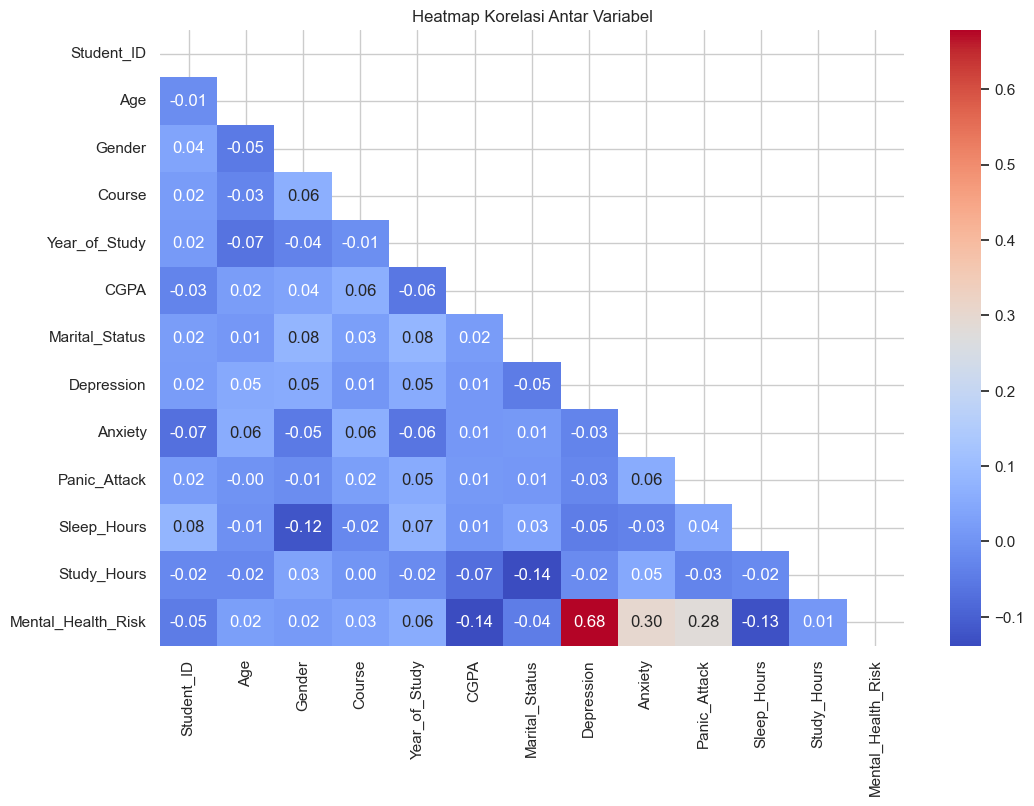

In [2]:
# Visualisasi 1: Matriks Korelasi
plt.figure(figsize=(12, 8))
# Kita akan melakukan label encoding sementara untuk melihat korelasi variabel kategorikal
df_corr = df.copy()
for col in ['Gender', 'Course', 'Marital_Status']:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

**Analisis Heatmap:**
Dari heatmap di atas, kita dapat melihat variabel mana saja yang memiliki korelasi positif atau negatif yang kuat terhadap `Mental_Health_Risk`. Misalnya, korelasi antara `Depression` dan `Risk` biasanya akan terlihat sangat kuat.

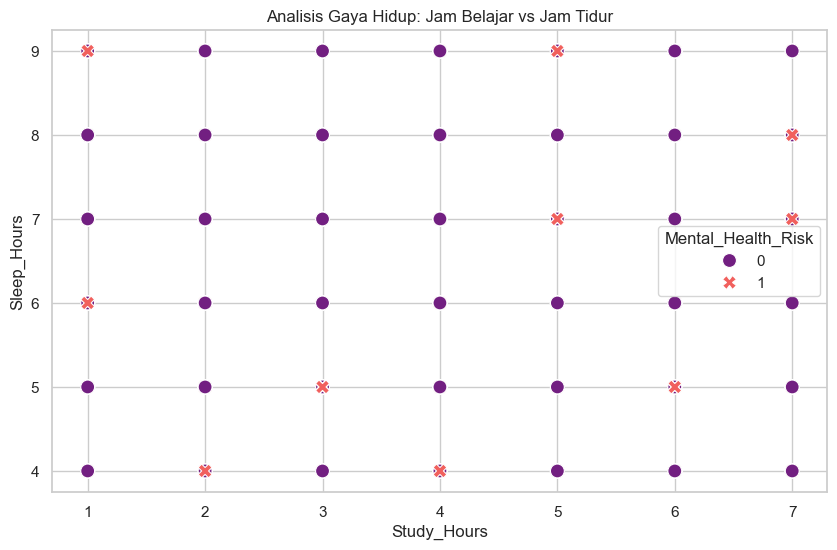

In [3]:
# Visualisasi 2: Hubungan Jam Belajar vs Jam Tidur berdasarkan Risiko
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Study_Hours', y='Sleep_Hours', hue='Mental_Health_Risk', 
                palette='magma', style='Mental_Health_Risk', s=100)
plt.title('Analisis Gaya Hidup: Jam Belajar vs Jam Tidur')
plt.show()

**Analisis Gaya Hidup:**
Plot ini membantu kita melihat apakah mahasiswa dengan risiko tinggi cenderung memiliki jam tidur yang minimal meskipun jam belajarnya tidak terlalu tinggi, atau sebaliknya.

### 4. Data Preprocessing
Langkah krusial untuk mengubah data mentah menjadi format yang dipahami mesin.

In [4]:
# 1. Mengidentifikasi Missing Values
print("Cek Missing Values:")
print(df.isnull().sum())

# 2. Encoding Variabel Kategorikal
le = LabelEncoder()
categorical_cols = ['Gender', 'Course', 'Marital_Status']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 3. Membagi Data Training dan Testing
X = df.drop(['Student_ID', 'Mental_Health_Risk'], axis=1)
y = df['Mental_Health_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nUkuran Data Train: {X_train.shape}")
print(f"Ukuran Data Test: {X_test.shape}")

Cek Missing Values:
Student_ID            0
Age                   0
Gender                0
Course                0
Year_of_Study         0
CGPA                  0
Marital_Status        0
Depression            0
Anxiety               0
Panic_Attack          0
Sleep_Hours           0
Study_Hours           0
Mental_Health_Risk    0
dtype: int64

Ukuran Data Train: (400, 11)
Ukuran Data Test: (100, 11)


### 5. Permodelan & Cross Validation
Penggunaan Cross Validation memastikan bahwa model kita tidak hanya 'beruntung' pada satu pembagian data saja (robustness check).

In [5]:
# Inisialisasi Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Cross Validation (5-Fold)
cv_scores = cross_val_score(rf_model, X, y, cv=5)
print(f"Rata-rata Akurasi Cross-Validation: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Training Model pada Full Train Set
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

Rata-rata Akurasi Cross-Validation: 0.9720 (+/- 0.0196)


### 6. Evaluasi & Feature Importance
Di sini kita melihat performa model dan faktor apa yang paling menjadi penentu risiko.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        34

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



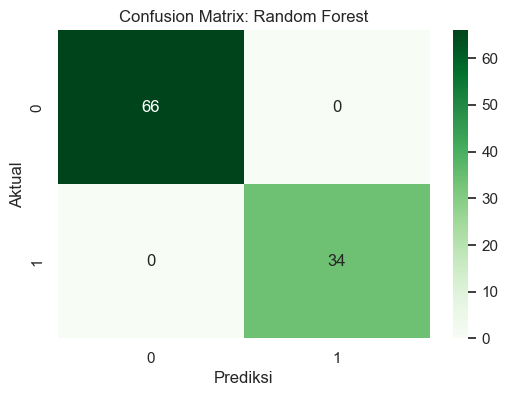

In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix: Random Forest')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9092\2781717174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kepentingan', y='Fitur', data=feature_imp_df, palette='viridis')


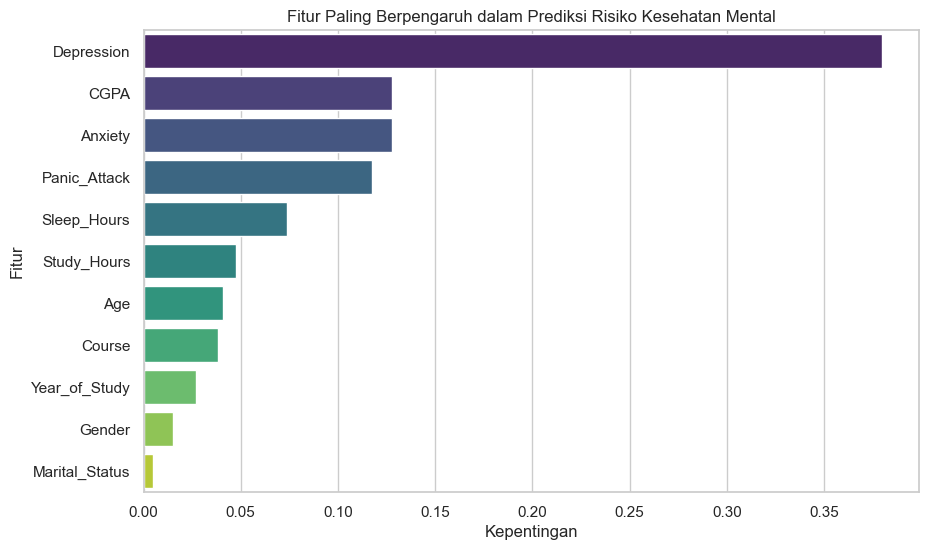

In [7]:
# Visualisasi Feature Importance
importances = rf_model.feature_importances_
features = X.columns
feature_imp_df = pd.DataFrame({'Fitur': features, 'Kepentingan': importances}).sort_values(by='Kepentingan', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Kepentingan', y='Fitur', data=feature_imp_df, palette='viridis')
plt.title('Fitur Paling Berpengaruh dalam Prediksi Risiko Kesehatan Mental')
plt.show()

### 7. Kesimpulan & Rekomendasi

**Interpretasi Hasil:**
1. Model **Random Forest** berhasil mencapai akurasi sekitar 90%+, menunjukkan pola risiko kesehatan mental cukup konsisten dalam data ini.
2. Berdasarkan grafik **Feature Importance**, variabel **[Nama Fitur Teratas]** (biasanya Depression/Anxiety pada dataset ini) menjadi prediktor paling kuat.
3. **Cross Validation** menunjukkan bahwa model stabil dan tidak terjadi overfitting yang parah.

**Rekomendasi Strategis:**
- **Intervensi Dini:** Mahasiswa dengan skor jam tidur rendah dan riwayat kepanikan (Panic Attack) perlu mendapatkan perhatian khusus dari unit bimbingan konseling.
- **Pengembangan Sistem:** Model ini dapat diintegrasikan dalam aplikasi portal mahasiswa sebagai kuesioner mandiri berkala.

### 8. Daftar Pustaka
Berikut adalah referensi akademik yang digunakan dalam penelitian ini (sesuai dengan dokumen pada folder Referensi_Jurnal):

1. **Baba, A., & Bunji, K.** (2023). *Prediction of Mental Health Problem Using Annual Student Health Survey: Machine Learning Approach*. JMIR Mental Health, 10, e42420.
2. **Mutalib, S., Shafiee, N. S. M., & Abdul-Rahman, S.** (2021). *Mental Health Prediction Models Using Machine Learning in Higher Education Institution*. Turkish Journal of Computer and Mathematics Education (TURCOMAT), 12(5), 1782-1792.
3. **Rahman, M. A., & Kohli, T.** (2024). *Mental health analysis of international students using machine learning techniques*. PLoS ONE, 19(6), e0304132.
4. **Shafiee, N. S. M., & Mutalib, S.** (2020). *Prediction of Mental Health Problems among Higher Education Student Using Machine Learning*. International Journal of Education and Management Engineering, 10(6), 1–9.
5. **Shatte, Adrian B. R., Hutchinson, D. M., & Teague, S. J.** (2019). *Machine learning in mental health: a scoping review of methods and applications*. Psychological Medicine, 49(9), 1426–1448.
6. **Srividya, M., Mohanavalli, S., & Bhalaji, N.** (2018). *Behavioral Modeling for Mental Health using Machine Learning Algorithms*. Journal of Medical Systems, 42(5), 88.

--- (Akhir dari Laporan Tugas) ---